## Medical Insurance Cost Prediction
 A Regression Analysis & Feature Engineering Approach
#### Overview
- This notebook explores the factors influencing individual medical insurance premiums. By leveraging Machine Learning (Linear Regression), we aim to predict healthcare costs based on demographic data and health habits.
#### Dataset: The analysis is performed on the Medical Cost Personal Dataset.
- Source: Insurance Dataset on Kaggle 🔗
##### Project Objectives
- Exploratory Data Analysis (EDA): Visualize key drivers such as Age, BMI, and Smoking status.
- Feature Engineering: Enhance the predictive power by capturing non-linear relationships and interaction terms.
-  Model Optimization: Build a robust Linear Regression model to forecast insurance costs with high accuracy.

In [1]:
import pandas as pd
import numpy as np 
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error , r2_score 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
df = pd.read_csv("/Users/aljawharah/Machine-learning-projects/supervised_learning/linear regression/insurance.csv")

#### EDA

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

--- Calculated Result (Mean Charges) ---
smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64




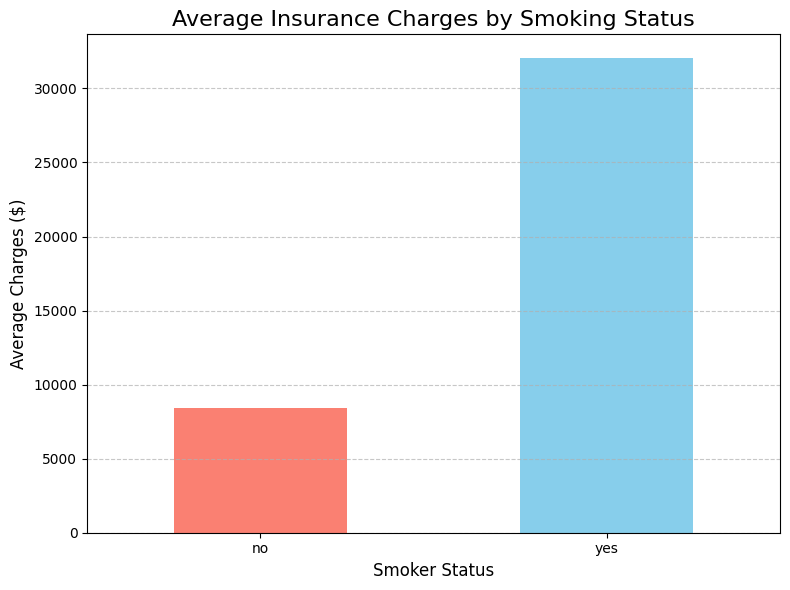

In [8]:

grouped_charges = df.groupby('smoker')['charges'].mean()

print("--- Calculated Result (Mean Charges) ---")
print(grouped_charges)
print("\n")


plt.figure(figsize=(8, 6)) # Set the figure size

# Plot 'grouped_charges' (which is a Series)
# Index ('no', 'yes') becomes the x-axis, values become the y-axis.
grouped_charges.plot(kind='bar', color=['salmon', 'skyblue'])


plt.title('Average Insurance Charges by Smoking Status', fontsize=16)
plt.xlabel('Smoker Status', fontsize=12)
plt.ylabel('Average Charges ($)', fontsize=12)

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

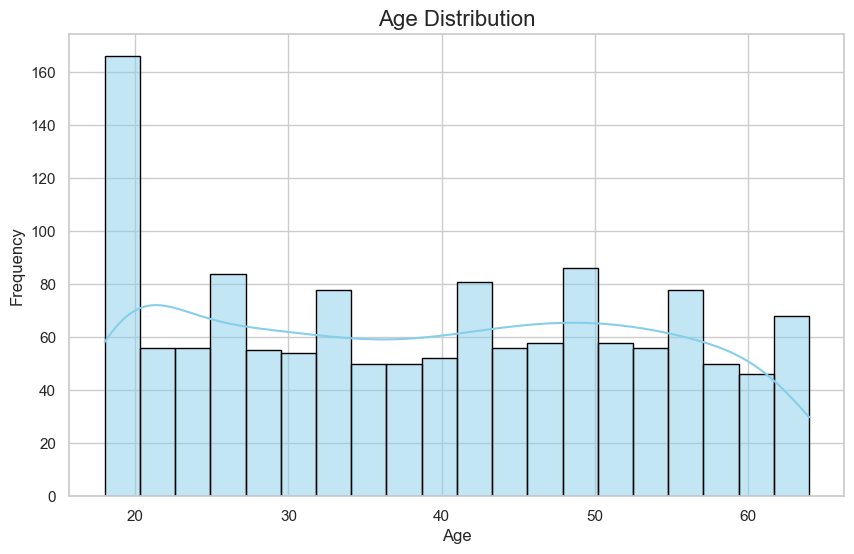

In [9]:
sns.set_theme(style = 'whitegrid')

plt.figure(figsize=(10, 6))

sns.histplot(df['age'], bins = 20 , kde=True, color='skyblue', edgecolor='black')

plt.title('Age Distribution', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show() 

/var/folders/33/14dhqm652058kft_rkfrx9d40000gn/T/ipykernel_37513/3085512743.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='children', palette='viridis')


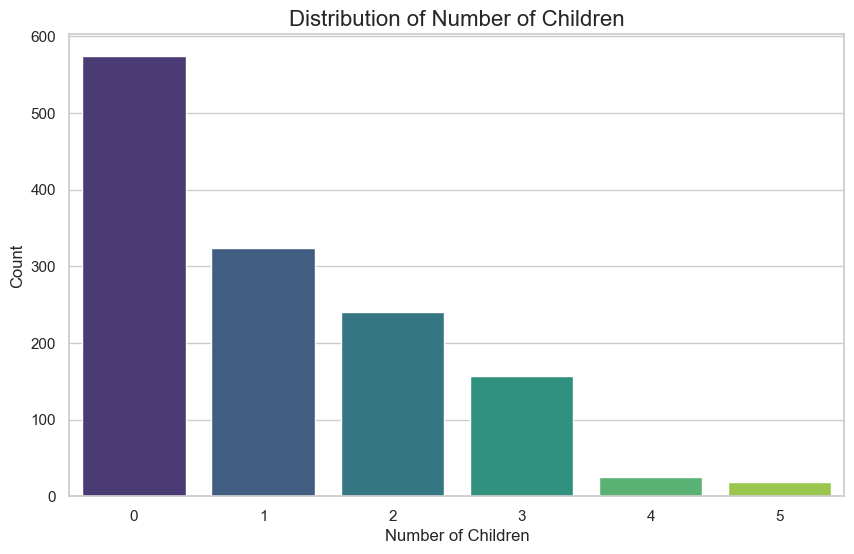

In [10]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
# 'children' is discrete, so countplot is perfect
sns.countplot(data=df, x='children', palette='viridis')

plt.title('Distribution of Number of Children', fontsize=16)
plt.xlabel('Number of Children', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

/var/folders/33/14dhqm652058kft_rkfrx9d40000gn/T/ipykernel_37513/3467777741.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='pastel')


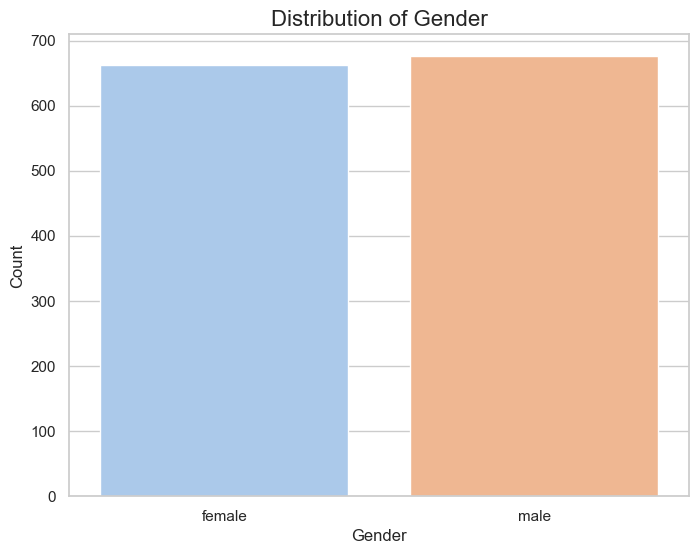

In [11]:
plt.figure(figsize=(8, 6))
# 'sex' is categorical
sns.countplot(data=df, x='sex', palette='pastel')

plt.title('Distribution of Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [12]:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the boundaries for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Filter the DataFrame to keep only the values within the bounds
df_clean = df[(df['charges'] >= lower_bound) & (df['charges'] <= upper_bound)]

# 4. Check the results
print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_clean)}")
print(f"Total outliers removed: {len(df) - len(df_clean)}")

Original dataset size: 1338
Cleaned dataset size: 1199
Total outliers removed: 139


In [13]:
# Simply remove any record where charges are higher than 45,000
df_clean = df[df['charges'] < 45000]

print(f"New dataset size: {len(df_clean)}")

New dataset size: 1300


### Data Preprocessing 

#### 1 .Encoding

In [14]:


print("Unique values in smoker:", df['smoker'].unique())
print("Unique values in sex:", df['sex'].unique())


Unique values in smoker: ['yes' 'no']
Unique values in sex: ['female' 'male']


In [15]:

df['smoker'] = df['smoker'].astype(str).str.lower().map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].astype(str).str.lower().map({'female': 1, 'male': 0})

df = pd.get_dummies(df, columns=['region'], drop_first=True)

for col in df.columns:
    if 'region_' in col:
        df[col] = df[col].astype(int)

print(df.head())

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    1  27.900         0       1  16884.92400                 0   
1   18    0  33.770         1       0   1725.55230                 0   
2   28    0  33.000         3       0   4449.46200                 0   
3   33    0  22.705         0       0  21984.47061                 1   
4   32    0  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


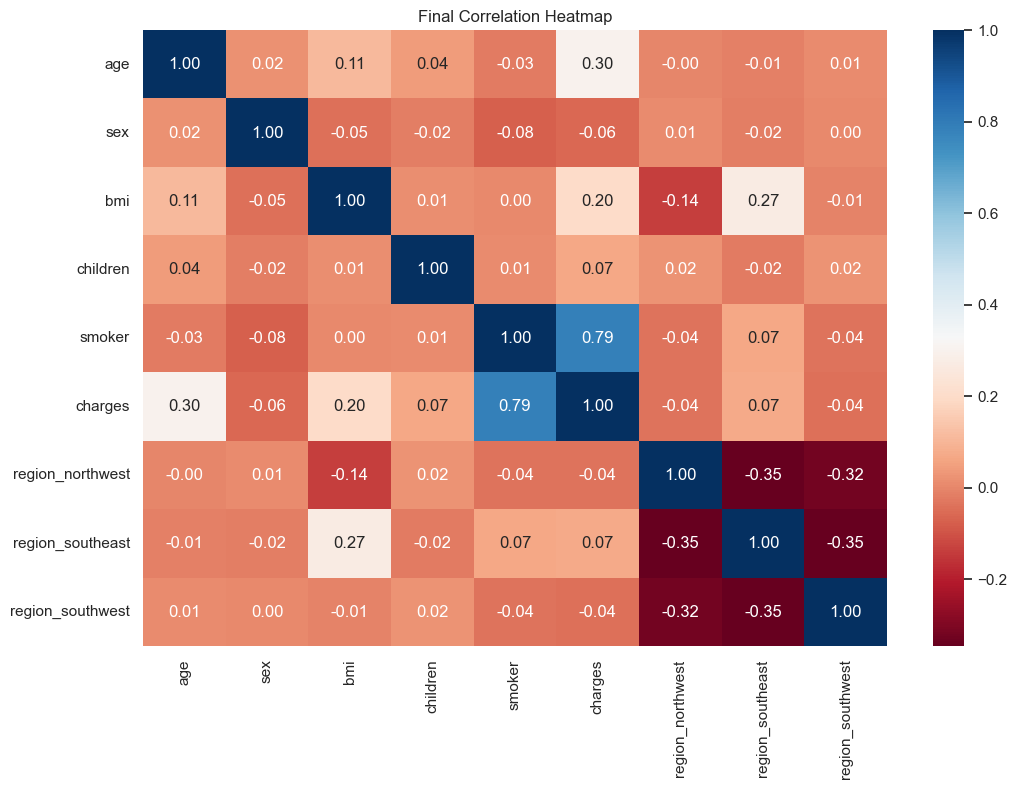

In [16]:

plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('Final Correlation Heatmap')
plt.show()

#### 2.Feature-Target Separation

In [17]:

df['bmi_smoker'] = df['bmi'] * df['smoker']

df['age_2'] = df['age'] ** 2

In [18]:
X = df.drop('charges' , axis=1)
y=df['charges']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (1338, 10)
Target (y) shape: (1338,)


#### 3.Train-Test Split

In [19]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 1070
Testing set size: 268


## Model fit

In [20]:
model = LinearRegression()

model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


testing

In [21]:

y_pred = model.predict(X_test)


In [22]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Squared Error (MSE): 20590480.74
Root Mean Squared Error (RMSE): 4537.67
R2 Score: 0.8674


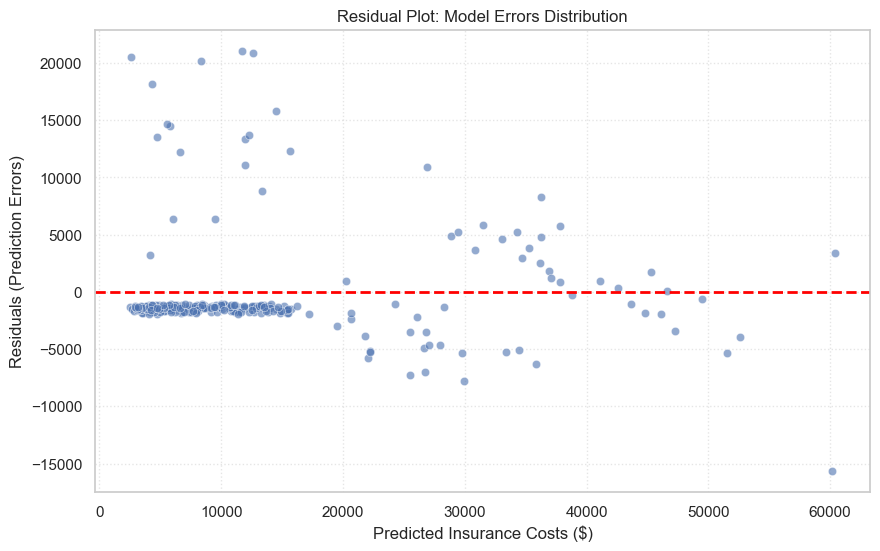

In [23]:
# 1. Calculate the residuals (The difference between actual and predicted values)
residuals = y_test - y_pred

# 2. Set up the figure for the visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)

# 3. Add a horizontal line at zero (Reference line for ideal predictions)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# 4. Final formatting and labels
plt.title('Residual Plot: Model Errors Distribution')
plt.xlabel('Predicted Insurance Costs ($)')
plt.ylabel('Residuals (Prediction Errors)')
plt.grid(True, linestyle=':', alpha=0.5)  # Added a light grid for better readability
plt.show()

## Model Performance & Final Insights
Evaluation Metrics

R 
2
 
 Score: 0.8674

The model successfully explains 86.7% of the variance in insurance costs. This demonstrates a strong fit and high reliability

RMSE: 4,537.67

Our predictions deviate by an average of $4,537. This is a significant improvement from our baseline model, thanks to refined feature engineering

#### Key Takeaways

The Power of Non-Linearity: Adding the Age-Squared (Age2) feature allowed the model to account for the accelerating cost of insurance as individuals age

Interaction Effects: The introduction of the BMI-Smoker interaction term was crucial. It captured the disproportionate cost spike seen in individuals who both smoke and have a high BMI

Conclusion: By moving beyond simple linear relationships, we achieved an 8% boost in accuracy (from 0.78 to 0.86), making the model much more suitable for real-world deployment